# Kinesin-14 Family — Phylogenetic Analysis

Based on:
- Neher Lab Auspice tutorial (2019): https://neherlab.org/201901_krisp_auspice.html
- pb3lab ibm3202 Lab 03 Phylogenetics

**Kinesin-14 highlights:**
- C-terminal motor domain (unique among kinesins)
- Minus-end directed (retrograde)
- Roles: spindle organisation, phragmoplast (plants), axonal transport (vertebrates)
- KIFC1/HSET: cancer drug target (centrosome clustering)

**Workflow:** fetch NCBI → align → trim → NJ + ML → coloured tree + heatmap + conservation → download

## Step 1 — Install dependencies

In [1]:
!pip install biopython --quiet
!apt-get install -y muscle fasttree --quiet
# Verify muscle binary name (older apt gives 'muscle', newer may differ)
import subprocess, shutil
MUSCLE_BIN = shutil.which('muscle') or shutil.which('muscle3') or 'muscle'
print('muscle binary:', MUSCLE_BIN)
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 18.8 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fasttree muscle
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 418 kB of archives.
After this operation, 1,207 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 muscle amd64 1:3.8.1551-2build1 [244 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fasttree amd64 2.1.11-2 [174 kB]
Fetched 418 kB in 1s (810 kB/s)
Selecting previously unselected package muscle.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../muscle_1%3a3.8.1551-2build1_amd64.deb ...
Unpacking muscle (1:3.8.1551-2build1) ...
Selecting previously unselected package fasttree.
Preparing to unpack .../fasttree_2.1.11-2_amd64.deb ...
Unpacking fasttree (2.1.11-2) ...
Setting up muscle

## Step 2 — Imports & helper functions

In [2]:
import os, time, subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import Entrez, SeqIO, AlignIO
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

Entrez.email = 'your_email@example.com'  # <-- CHANGE THIS
print('BioPython', __import__('Bio').__version__, '— all imports OK')

BioPython 1.87 — all imports OK


In [3]:
def run_muscle(in_fasta, out_fasta):
    """Run MUSCLE alignment using subprocess (works with all BioPython versions)."""
    cmd = [MUSCLE_BIN, '-in', in_fasta, '-out', out_fasta]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        # Newer MUSCLE v5 uses different flags
        cmd = [MUSCLE_BIN, '-align', in_fasta, '-output', out_fasta]
        result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print('MUSCLE stderr:', result.stderr[:500])
        raise RuntimeError('MUSCLE alignment failed')
    return out_fasta

def trim(aln, thr=0.5):
    """Remove alignment columns with > thr gap fraction."""
    n = len(aln)
    keep = [i for i in range(aln.get_alignment_length())
            if aln[:, i].count('-') / n <= thr]
    t = aln[:, keep[0]:keep[0]+1]
    for i in keep[1:]:
        t = t + aln[:, i:i+1]
    return t

def fetch(acc, lbl):
    """Fetch one protein sequence from NCBI."""
    try:
        h = Entrez.efetch(db='protein', id=acc, rettype='fasta', retmode='text')
        r = SeqIO.read(h, 'fasta'); h.close()
        r.id = r.name = lbl
        r.description = f'{lbl}|{acc}'
        time.sleep(0.4)   # respect NCBI rate limit
        return r
    except Exception as e:
        print(f'  FAIL {lbl}: {e}')
        return None

print('Helper functions defined OK')

Helper functions defined OK


## Step 3 — Define Kinesin-14 sequences across eukaryotes

In [4]:
kin14_seqs = {
    # Vertebrates
    'KIFC1_Hsap' : 'NP_002254',     # HSET human — cancer target
    'KIFC2_Hsap' : 'NP_008938',     # neuronal dendrite transport
    'KIFC3_Hsap' : 'NP_008942',     # minus-end vesicle transport
    'KIFC1_Mmus' : 'NP_032468',     # mouse ortholog
    'XCTK2_Xlae' : 'NP_001079543',  # Xenopus spindle
    'KIFC1_Drer' : 'XP_001921107',  # zebrafish
    # Invertebrates
    'NCD_Dmel'   : 'NP_476999',     # prototype Kin-14; meiosis/mitosis
    'KLP15_Cele' : 'NP_001255892',  # C. elegans
    # Fungi
    'KAR3_Scer'  : 'NP_013360',     # yeast karyogamy and spindle
    'PKL1_Spom'  : 'NP_596168',     # S. pombe spindle pole body
    'KLPA_Anid'  : 'XP_659076',     # Aspergillus
    'KLP3_Ncra'  : 'XP_959853',     # Neurospora
    # Plants
    'ATK1_Atha'  : 'NP_177710',     # Arabidopsis phragmoplast
    'ATK5_Atha'  : 'NP_200602',     # Arabidopsis pollen tube
    'KCBP_Atha'  : 'NP_849989',     # calmodulin-binding; trichomes
    'KIN14_Ppat' : 'XP_001754543',  # Physcomitrella
    # Algae / Protists
    'KIN14_Crei' : 'XP_001692040',  # Chlamydomonas
    'KIN14_Tgon' : 'XP_002365791',  # Toxoplasma
}

GROUP = {
    'Hsap':'Vertebrate','Mmus':'Vertebrate','Xlae':'Vertebrate',
    'Drer':'Vertebrate','Ggal':'Vertebrate',
    'Dmel':'Invertebrate','Cele':'Invertebrate',
    'Scer':'Fungi','Spom':'Fungi','Anid':'Fungi','Ncra':'Fungi',
    'Atha':'Plant','Ppat':'Plant','Osat':'Plant',
    'Crei':'AlgaeProtist','Tgon':'AlgaeProtist',
}
GRP_COL = {
    'Vertebrate':'#E74C3C','Invertebrate':'#E67E22',
    'Fungi':'#9B59B6','Plant':'#27AE60','AlgaeProtist':'#3498DB',
}
def get_group(lbl):
    for abbr, grp in GROUP.items():
        if abbr in lbl: return grp
    return 'Unknown'
def get_col(lbl):
    return GRP_COL.get(get_group(lbl), '#aaa')

from collections import Counter
print(f'Defined {len(kin14_seqs)} Kinesin-14 sequences.')
for g, n in Counter(get_group(l) for l in kin14_seqs).items():
    print(f'  {g:<16}: {n}')

Defined 18 Kinesin-14 sequences.
  Vertebrate      : 6
  Invertebrate    : 2
  Fungi           : 4
  Plant           : 4
  AlgaeProtist    : 2


## Step 4 — Fetch from NCBI Entrez

In [5]:
records = []
for lbl, acc in kin14_seqs.items():
    print(f'  [{get_group(lbl):<14}] {lbl:<14} [{acc}]...', end=' ')
    r = fetch(acc, lbl)
    if r:
        records.append(r)
        print(f'OK {len(r.seq)} aa')

SeqIO.write(records, 'k14_raw.fasta', 'fasta')
print(f'\nFetched {len(records)}/{len(kin14_seqs)}')

  [Vertebrate    ] KIFC1_Hsap     [NP_002254]... OK 673 aa
  [Vertebrate    ] KIFC2_Hsap     [NP_008938]... OK 551 aa
  [Vertebrate    ] KIFC3_Hsap     [NP_008942]... OK 425 aa
  [Vertebrate    ] KIFC1_Mmus     [NP_032468]... OK 716 aa
  [Vertebrate    ] XCTK2_Xlae     [NP_001079543]... OK 261 aa
  [Vertebrate    ] KIFC1_Drer     [XP_001921107]... OK 786 aa
  [Invertebrate  ] NCD_Dmel       [NP_476999]... OK 622 aa
  [Invertebrate  ] KLP15_Cele     [NP_001255892]... OK 301 aa
  [Fungi         ] KAR3_Scer      [NP_013360]... OK 572 aa
  [Fungi         ] PKL1_Spom      [NP_596168]... OK 390 aa
  [Fungi         ] KLPA_Anid      [XP_659076]... OK 395 aa
  [Fungi         ] KLP3_Ncra      [XP_959853]... OK 571 aa
  [Plant         ] ATK1_Atha      [NP_177710]... OK 980 aa
  [Plant         ] ATK5_Atha      [NP_200602]... OK 717 aa
  [Plant         ] KCBP_Atha      [NP_849989]... OK 367 aa
  [Plant         ] KIN14_Ppat     [XP_001754543]... OK 218 aa
  [AlgaeProtist  ] KIN14_Crei     [XP_001692

## Step 5 — MUSCLE alignment + trim

In [6]:
print('Running MUSCLE ...')
run_muscle('k14_raw.fasta', 'k14_aln.fasta')
aln = AlignIO.read('k14_aln.fasta', 'fasta')
print(f'Aligned: {len(aln)} seqs x {aln.get_alignment_length()} cols')

trm = trim(aln)
AlignIO.write(trm, 'k14_trim.fasta', 'fasta')
print(f'Trimmed: {trm.get_alignment_length()} cols')

Running MUSCLE ...
Aligned: 18 seqs x 1010 cols
Trimmed: 517 cols


## Step 6 — Conservation plot (Auspice diversity panel equivalent)

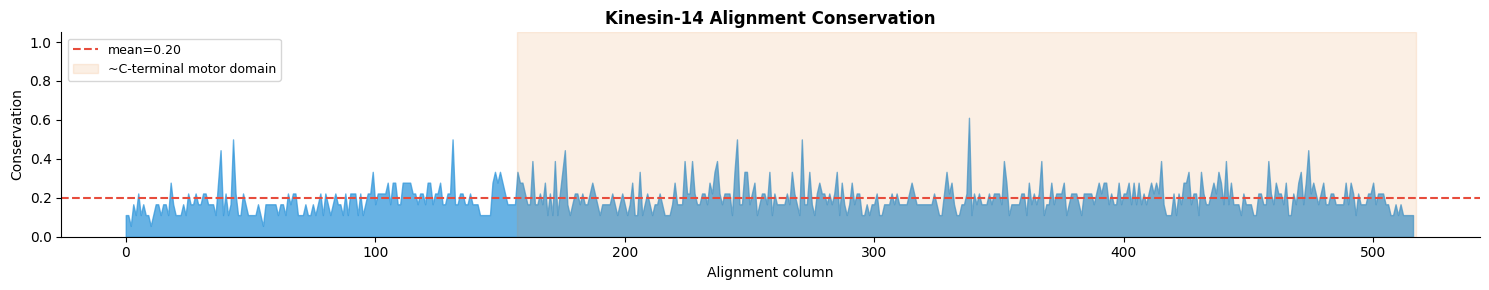

In [7]:
def conservation(aln):
    n = len(aln)
    out = []
    for i in range(aln.get_alignment_length()):
        col = aln[:, i].upper().replace('-', '')
        out.append(max((col.count(aa) for aa in set(col)), default=0) / n if col else 0)
    return out

cons = conservation(trm)
fig, ax = plt.subplots(figsize=(15, 3))
ax.fill_between(range(len(cons)), cons, alpha=0.75, color='#3498DB')
ax.axhline(np.mean(cons), color='#E74C3C', linestyle='--',
           label=f'mean={np.mean(cons):.2f}')
md_start = max(0, len(cons) - 360)
ax.axvspan(md_start, len(cons), alpha=0.12, color='#E67E22',
           label='~C-terminal motor domain')
ax.set_xlabel('Alignment column'); ax.set_ylabel('Conservation')
ax.set_title('Kinesin-14 Alignment Conservation', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05); ax.legend(fontsize=9)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig('k14_conservation.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Tree inference
### 7a Neighbour-Joining

In [8]:
calc = DistanceCalculator('blosum62')
nj = DistanceTreeConstructor(calc, 'nj').build_tree(trm)
Phylo.write(nj, 'k14_nj.nwk', 'newick')
print('NJ tree saved.')
Phylo.draw_ascii(nj)

NJ tree saved.
   __________________________________________________________ KLP15_Cele
 ,|
 ||____________________________________________________________ NCD_Dmel
 |
 |  __________________________________________________________ KIFC1_Hsap
 |_|
 | |_____________________________________________________________ ATK5_Atha
 |
 |____________________________________________________________ KIFC1_Drer
 |
 | ___________________________________________________________ KLP3_Ncra
 ||
 ||___________________________________________________________ ATK1_Atha
 ||
 || _________________________________________________________ KIN14_Ppat
 |||
 |||___________________________________________________________ KLPA_Anid
 ||
 ||  _________________________________________________________ KIFC3_Hsap
_||_|
 |  |__________________________________________________________ PKL1_Spom
 |
 |  ____________________________________________________________ KIFC2_Hsap
 |_|
 | |_____________________________________________

### 7b Maximum Likelihood — FastTree (WAG+Gamma)

In [9]:
!FastTree -wag -gamma k14_trim.fasta > k14_ml.nwk 2>k14_ft.log
if os.path.exists('k14_ml.nwk') and os.path.getsize('k14_ml.nwk') > 0:
    ml = Phylo.read('k14_ml.nwk', 'newick')
    print(f'ML tree: {ml.count_terminals()} tips')
    Phylo.draw_ascii(ml)
else:
    print('FastTree failed — log:')
    print(open('k14_ft.log').read())

ML tree: 18 tips
    _____________________________________ KIFC1_Drer
  ,|
  ||       ______________________________ PKL1_Spom
 ,||______|
 ||       |______________________________ KIFC3_Hsap
 ||
 ||___________________________________ KLP3_Ncra
 |
 | ________________________________ KIN14_Ppat
 ||
 ||                ______________________________________________ ATK5_Atha
 ||  _____________|
_||_|             |_______________________ KLPA_Anid
 |  |
 |  |__________________________________ ATK1_Atha
 |
 |     _________________________________ KLP15_Cele
 |    |
 |    |  ________________________________________ KCBP_Atha
 |    | |
 |    | |         _________________________________ NCD_Dmel
 |    | |      __|
 |____|,|     |  |   __________________________________ KIN14_Tgon
      |||     |  |__|
      |||   __|     |________________________________ KIFC1_Hsap
      |||  |  |
      |||  |  |      ________________________ KIN14_Crei
      |||__|  |_____|
      ||   |        |_____________

## Step 8 — Colour-coded phylogeny figure (by organism group)

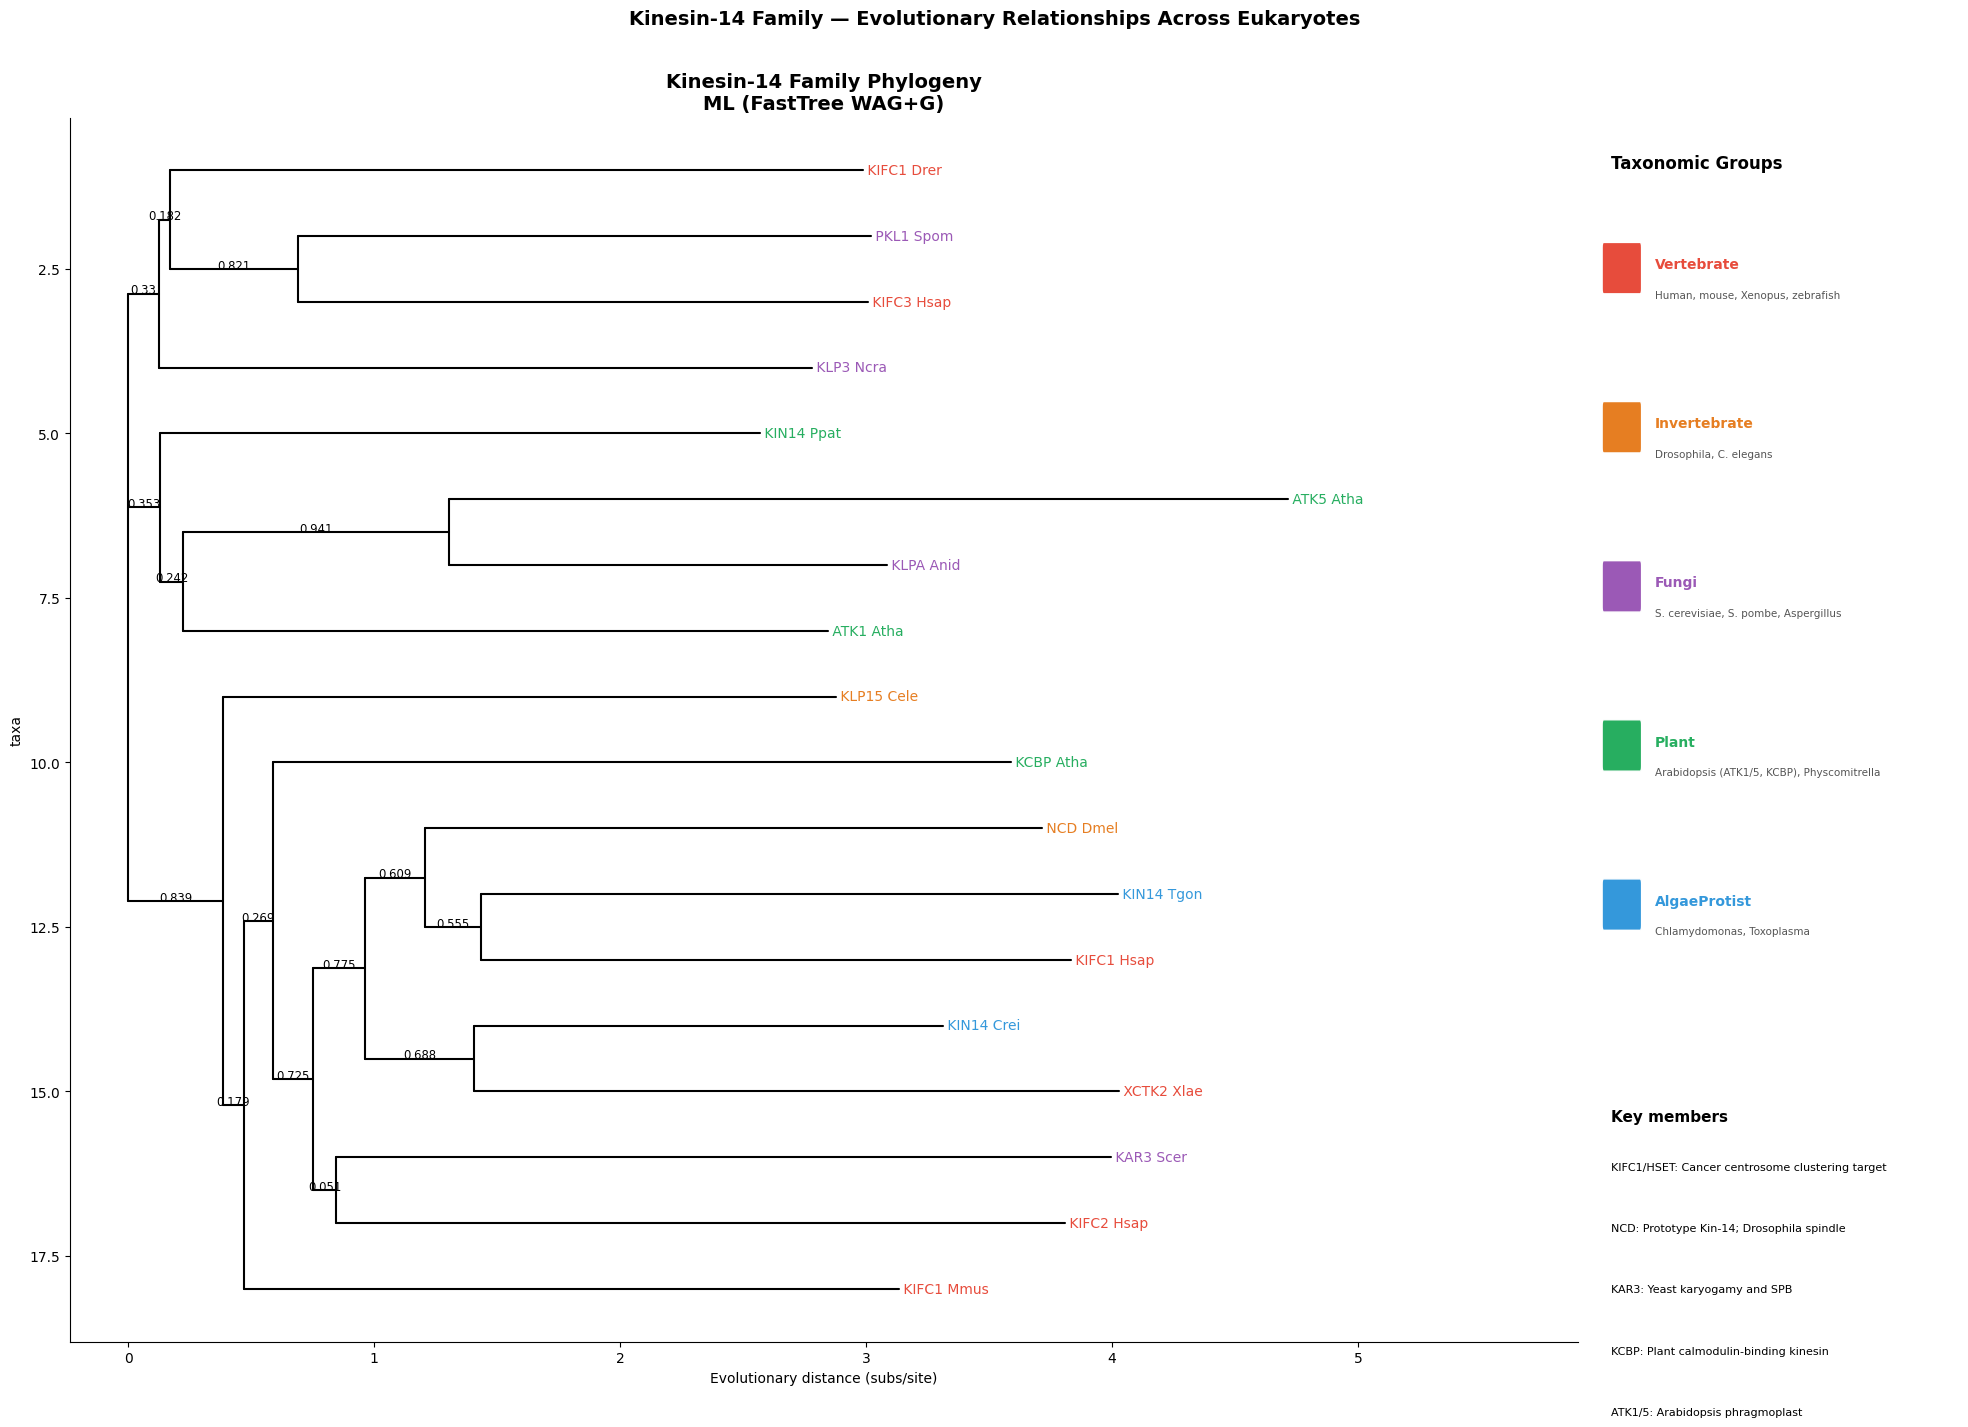

In [10]:
try:
    pt = Phylo.read('k14_ml.nwk', 'newick'); tree_lbl = 'ML (FastTree WAG+G)'
except Exception:
    pt = nj; tree_lbl = 'NJ (BLOSUM62)'

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(1, 5)
ax1 = fig.add_subplot(gs[0, :4])
ax2 = fig.add_subplot(gs[0, 4])

Phylo.draw(pt, axes=ax1, do_show=False,
           label_func=lambda x: x.name.replace('_',' ') if x.is_terminal() else '',
           label_colors=lambda n: get_col(n) if n else 'black')
ax1.set_title(f'Kinesin-14 Family Phylogeny\n{tree_lbl}',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Evolutionary distance (subs/site)')
for s in ['top','right']: ax1.spines[s].set_visible(False)

ax2.axis('off')
ax2.text(0.05, 0.97, 'Taxonomic Groups', fontsize=12, fontweight='bold',
         transform=ax2.transAxes, va='top')
GRPS = [
    ('Vertebrate',   '#E74C3C', 'Human, mouse, Xenopus, zebrafish'),
    ('Invertebrate', '#E67E22', 'Drosophila, C. elegans'),
    ('Fungi',        '#9B59B6', 'S. cerevisiae, S. pombe, Aspergillus'),
    ('Plant',        '#27AE60', 'Arabidopsis (ATK1/5, KCBP), Physcomitrella'),
    ('AlgaeProtist', '#3498DB', 'Chlamydomonas, Toxoplasma'),
]
y = 0.88
for grp, col, members in GRPS:
    ax2.add_patch(mpatches.FancyBboxPatch((0.03, y-0.02), 0.1, 0.034,
        boxstyle='round,pad=0.004', facecolor=col, edgecolor='white',
        transform=ax2.transAxes))
    ax2.text(0.17, y, grp, fontsize=10, fontweight='bold', color=col,
             transform=ax2.transAxes, va='center')
    ax2.text(0.17, y-0.025, members, fontsize=7.5, color='#555',
             transform=ax2.transAxes, va='center')
    y -= 0.13
y -= 0.05
ax2.text(0.05, y, 'Key members', fontsize=11, fontweight='bold',
         transform=ax2.transAxes)
y -= 0.04
for name, desc in [
    ('KIFC1/HSET', 'Cancer centrosome clustering target'),
    ('NCD', 'Prototype Kin-14; Drosophila spindle'),
    ('KAR3', 'Yeast karyogamy and SPB'),
    ('KCBP', 'Plant calmodulin-binding kinesin'),
    ('ATK1/5', 'Arabidopsis phragmoplast'),
]:
    ax2.text(0.05, y, f'{name}: {desc}', fontsize=8, transform=ax2.transAxes)
    y -= 0.05

plt.suptitle('Kinesin-14 Family — Evolutionary Relationships Across Eukaryotes',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('k14_phylogeny.pdf', dpi=150, bbox_inches='tight')
plt.savefig('k14_phylogeny.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Pairwise distance heatmap

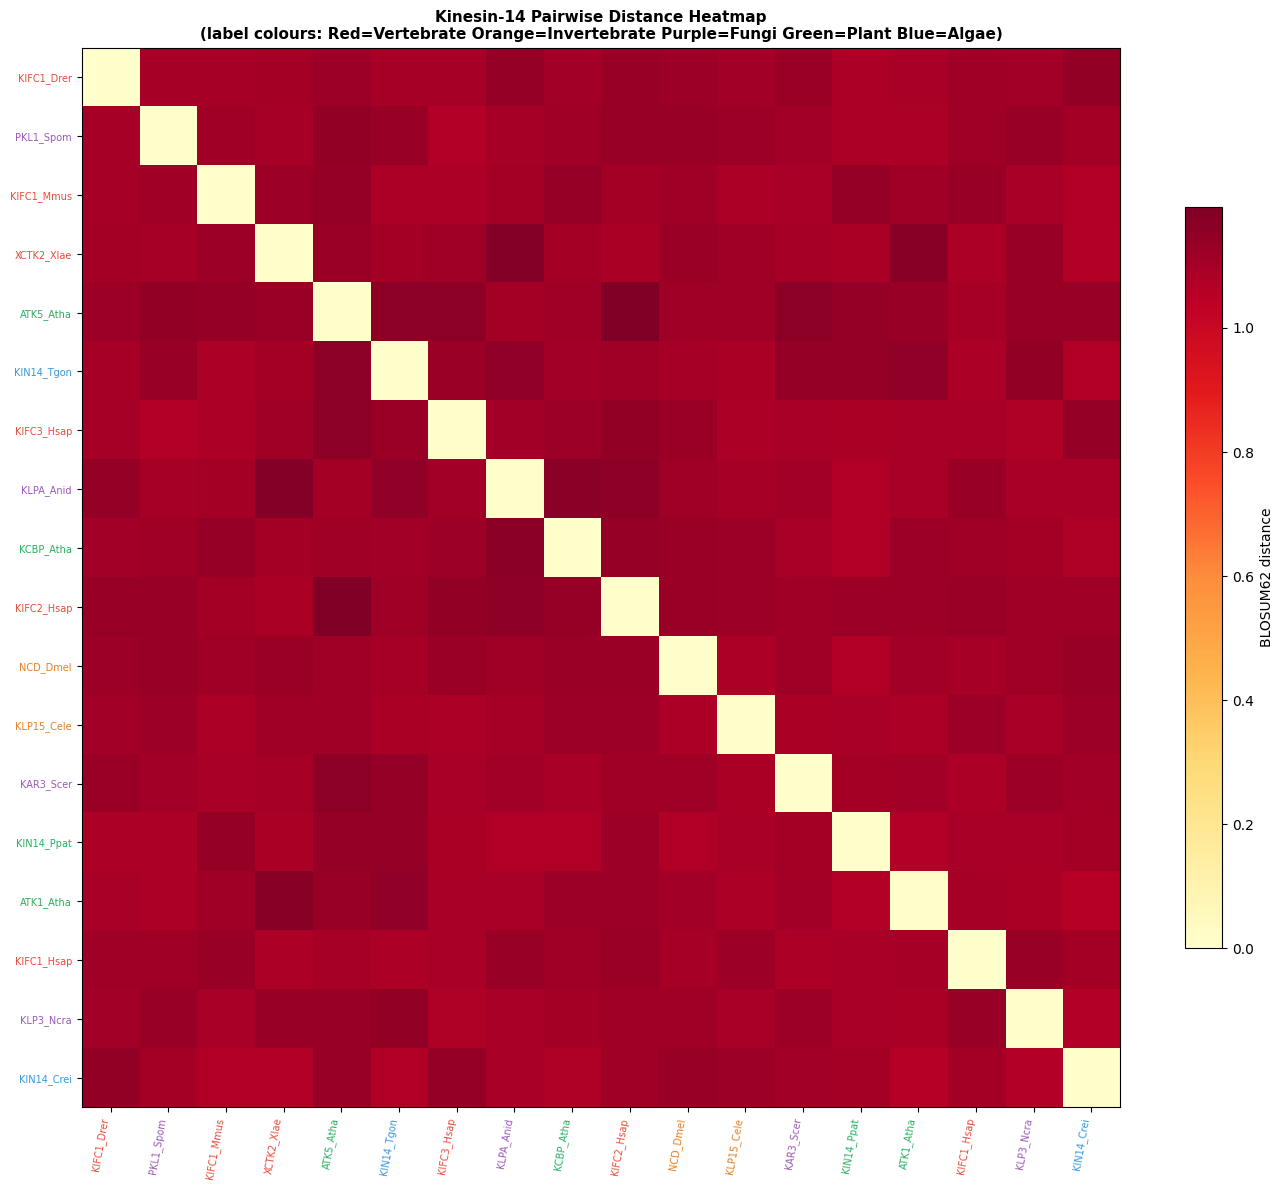

In [11]:
calc2 = DistanceCalculator('blosum62')
dm = calc2.get_distance(trm)
names = [r.id for r in trm]
n = len(names)
M = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j: M[i, j] = dm[names[i], names[j]]

gcols = [GRP_COL.get(get_group(nm), '#aaa') for nm in names]
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(M, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=80, ha='right', fontsize=7)
ax.set_yticklabels(names, fontsize=7)
for tick, c in zip(ax.get_xticklabels(), gcols): tick.set_color(c)
for tick, c in zip(ax.get_yticklabels(), gcols): tick.set_color(c)
plt.colorbar(im, ax=ax, label='BLOSUM62 distance', shrink=0.7)
ax.set_title('Kinesin-14 Pairwise Distance Heatmap\n'
             '(label colours: Red=Vertebrate Orange=Invertebrate '
             'Purple=Fungi Green=Plant Blue=Algae)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('k14_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Cross-group distance statistics

In [12]:
from itertools import combinations
try: st = Phylo.read('k14_ml.nwk', 'newick')
except Exception: st = nj
bls = [c.branch_length for c in st.find_clades() if c.branch_length]
print(f'Tips: {st.count_terminals()}')
print(f'Total BL: {st.total_branch_length():.4f}')
print(f'Mean BL:  {np.mean(bls):.5f}   Max: {max(bls):.5f}')

grp_lbl = [get_group(nm) for nm in names]
uniq = sorted(set(grp_lbl))
print('\nMean intra-group distances:')
for g in uniq:
    idx = [i for i, gl in enumerate(grp_lbl) if gl == g]
    if len(idx) < 2: continue
    d = [M[i][j] for i, j in combinations(idx, 2)]
    print(f'  {g:<16}: {np.mean(d):.4f} +/- {np.std(d):.4f}')
print('\nMean inter-group distances:')
for g1, g2 in combinations(uniq, 2):
    i1 = [i for i, gl in enumerate(grp_lbl) if gl == g1]
    i2 = [i for i, gl in enumerate(grp_lbl) if gl == g2]
    if not i1 or not i2: continue
    d = [M[i][j] for i in i1 for j in i2]
    print(f'  {g1:<14} vs {g2:<14}: {np.mean(d):.4f}')

Tips: 18
Total BL: 50.6347
Mean BL:  1.53439   Max: 3.41129

Mean intra-group distances:
  AlgaeProtist    : 1.0705 +/- 0.0000
  Fungi           : 1.1115 +/- 0.0125
  Invertebrate    : 1.0836 +/- 0.0000
  Plant           : 1.1084 +/- 0.0295
  Vertebrate      : 1.1103 +/- 0.0179

Mean inter-group distances:
  AlgaeProtist   vs Fungi         : 1.1185
  AlgaeProtist   vs Invertebrate  : 1.1112
  AlgaeProtist   vs Plant         : 1.1168
  AlgaeProtist   vs Vertebrate    : 1.1061
  Fungi          vs Invertebrate  : 1.1115
  Fungi          vs Plant         : 1.1092
  Fungi          vs Vertebrate    : 1.1137
  Invertebrate   vs Plant         : 1.1065
  Invertebrate   vs Vertebrate    : 1.1128
  Plant          vs Vertebrate    : 1.1203


## Step 11 — Export Newick + iTOL colour annotation

In [13]:
try:
    print('Newick string (paste into iTOL / Phylo.io / FigTree):\n')
    print(open('k14_ml.nwk').read()[:600], '...')
except Exception: pass

itol = 'TREE_COLORS\nSEPARATOR TAB\nDATA\n'
for nm in names:
    itol += f'{nm}\tlabel\t{get_col(nm)}\tnormal\t2\n'
with open('k14_itol_colors.txt', 'w') as f: f.write(itol)
print('iTOL colour file saved: k14_itol_colors.txt')

Newick string (paste into iTOL / Phylo.io / FigTree):

(((KIFC1_Drer:2.816607565,(PKL1_Spom:2.326982590,KIFC3_Hsap:2.314653973)0.821:0.521284109)0.182:0.044906223,KLP3_Ncra:2.654880726)0.330:0.126067643,(KIN14_Ppat:2.439831502,((ATK5_Atha:3.411294551,KLPA_Anid:1.784171503)0.941:1.078067620,ATK1_Atha:2.621506442)0.242:0.093924177)0.353:0.131021233,(KLP15_Cele:2.490419160,((KCBP_Atha:3.001431234,(((NCD_Dmel:2.506051703,(KIN14_Tgon:2.590022419,KIFC1_Hsap:2.399001730)0.555:0.226863654)0.609:0.246187223,(KIN14_Crei:1.907130236,XCTK2_Xlae:2.621584784)0.688:0.445145721)0.775:0.208413925,(KAR3_Scer:3.150839731,KIFC2_Hsap:2.965085944)0.051:0.092185238)0.72 ...
iTOL colour file saved: k14_itol_colors.txt


## Step 12 — Download all results

In [14]:
from google.colab import files
import zipfile
outs = ['k14_raw.fasta','k14_aln.fasta','k14_trim.fasta',
        'k14_nj.nwk','k14_ml.nwk',
        'k14_phylogeny.pdf','k14_phylogeny.png',
        'k14_conservation.png','k14_heatmap.png','k14_itol_colors.txt']
with zipfile.ZipFile('kinesin14_results.zip', 'w') as zf:
    for f in outs:
        if os.path.exists(f): zf.write(f); print(f'  added {f}')
files.download('kinesin14_results.zip')

  added k14_raw.fasta
  added k14_aln.fasta
  added k14_trim.fasta
  added k14_nj.nwk
  added k14_ml.nwk
  added k14_phylogeny.pdf
  added k14_phylogeny.png
  added k14_conservation.png
  added k14_heatmap.png
  added k14_itol_colors.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>